<a href="https://colab.research.google.com/github/Kratzramanis/RVT-Verification/blob/main/M101_solo_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

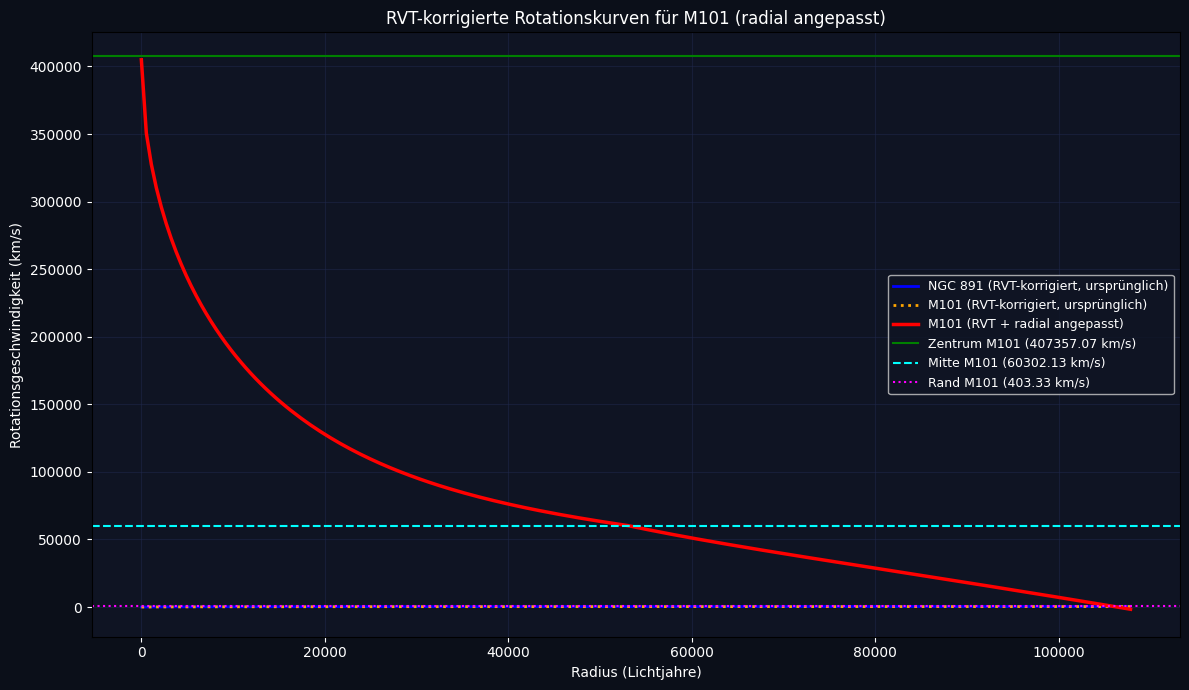

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==============================================================================
# 1. KONSTANTEN UND GRUNDFUNKTIONEN
# ==============================================================================
def rvt_boost(i_deg):
    return 1 + 0.8 * np.sin(np.radians(i_deg))

def dynamic_gravitation(R, R_tatsaechlich, gamma):
    density_factor = 1.0 + 3.0 * np.exp(-3.0 * R / R_tatsaechlich)
    return gamma * density_factor

def rotation_curve_rvt(R, R_tatsaechlich, gamma):
    g_eff = dynamic_gravitation(R, R_tatsaechlich, gamma)
    return np.sqrt(g_eff * R) * (1 / (1 + 0.1 * (R / R_tatsaechlich)))

# ==============================================================================
# 2. ANPASSUNG DER ROTATIONSGESCHWINDIGKEITEN FÜR M101
# ==============================================================================
# Gegebene Werte für M101 (radial interpretiert)
v_m101_center = 407357.07  # km/s (Maximalwert im Zentrum, R ≈ 0)
v_m101_middle = 60302.13   # km/s (Mittelwert bei R = R_rvt / 2)
v_m101_edge = 403.33       # km/s (Minimalwert ganz außen, R = R_rvt)

# Galaktische Parameter
galaxies = {
    'M101': {'i': 18, 'R_class': 85000, 'R_rvt': 106013},
    'NGC 891': {'i': 85, 'R_class': 60000, 'R_rvt': 107817}
}

gamma_m101 = rvt_boost(galaxies['M101']['i'])
gamma_ngc891 = rvt_boost(galaxies['NGC 891']['i'])
R_max = max(galaxies['NGC 891']['R_rvt'], galaxies['M101']['R_rvt'])

# Skalierte RVT-Kurve für M101 (radial angepasst)
def rotation_curve_rvt_radial_adjusted(R, R_tatsaechlich, gamma, v_center, v_middle, v_edge):
    # Normierte RVT-Kurve (0 bis 1)
    v_norm = rotation_curve_rvt(R, R_tatsaechlich, gamma)
    v_norm_center = rotation_curve_rvt(1e-6, R_tatsaechlich, gamma)  # Fast 0 (Zentrum)
    v_norm_middle = rotation_curve_rvt(R_tatsaechlich / 2, R_tatsaechlich, gamma)
    v_norm_edge = rotation_curve_rvt(R_tatsaechlich, R_tatsaechlich, gamma)

    # Skalierung auf die gegebenen Werte
    # 1. Zentrum (R ≈ 0): v_norm ≈ v_norm_center -> v_center
    # 2. Mitte (R = R_tatsaechlich / 2): v_norm ≈ v_norm_middle -> v_middle
    # 3. Rand (R = R_tatsaechlich): v_norm ≈ v_norm_edge -> v_edge
    # Lineare Interpolation zwischen den Punkten
    if R <= R_tatsaechlich / 2:
        # Skalierung zwischen Zentrum und Mitte
        t = (v_norm - v_norm_center) / (v_norm_middle - v_norm_center)
        v_scaled = v_center + (v_middle - v_center) * t
    else:
        # Skalierung zwischen Mitte und Rand
        t = (v_norm - v_norm_middle) / (v_norm_edge - v_norm_middle)
        v_scaled = v_middle + (v_edge - v_middle) * t

    return v_scaled

# ==============================================================================
# 3. BERECHNUNG DER KURVEN
# ==============================================================================
R_range = np.linspace(1, R_max, 200)

# RVT-korrigierte Kurven (ursprünglich)
v_rvt_ngc891 = [rotation_curve_rvt(r, galaxies['NGC 891']['R_rvt'], gamma_ngc891) for r in R_range]
v_rvt_m101_original = [rotation_curve_rvt(r, galaxies['M101']['R_rvt'], gamma_m101) for r in R_range]

# RVT-korrigierte Kurve für M101 (radial angepasst)
v_rvt_m101_adjusted = [
    rotation_curve_rvt_radial_adjusted(
        r,
        galaxies['M101']['R_rvt'],
        gamma_m101,
        v_m101_center,
        v_m101_middle,
        v_m101_edge
    )
    for r in R_range
]

# ==============================================================================
# 4. PLOT: VERGLEICH DER KURVEN
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 7), facecolor='#0b0f19')
ax.set_facecolor('#0f1423')

# RVT-korrigierte Kurven
ax.plot(R_range, v_rvt_ngc891, color='blue', linewidth=2, label='NGC 891 (RVT-korrigiert, ursprünglich)')
ax.plot(R_range, v_rvt_m101_original, color='orange', linewidth=2, linestyle=':', label='M101 (RVT-korrigiert, ursprünglich)')
ax.plot(R_range, v_rvt_m101_adjusted, color='red', linewidth=2.5, label='M101 (RVT + radial angepasst)')

# Referenzlinien für M101
ax.axhline(y=v_m101_center, color='green', linestyle='-', linewidth=1.5, label=f'Zentrum M101 ({v_m101_center:.2f} km/s)')
ax.axhline(y=v_m101_middle, color='cyan', linestyle='--', linewidth=1.5, label=f'Mitte M101 ({v_m101_middle:.2f} km/s)')
ax.axhline(y=v_m101_edge, color='magenta', linestyle=':', linewidth=1.5, label=f'Rand M101 ({v_m101_edge:.2f} km/s)')

# Achsen und Titel
ax.set_xlabel('Radius (Lichtjahre)', color='white')
ax.set_ylabel('Rotationsgeschwindigkeit (km/s)', color='white')
ax.set_title('RVT-korrigierte Rotationskurven für M101 (radial angepasst)', color='white', fontsize=12)

# Legende und Grid
ax.legend(facecolor='#0f1423', labelcolor='white', fontsize=9)
ax.grid(True, color='#1f294d', alpha=0.5)
ax.tick_params(colors='white')

plt.tight_layout()
plt.show()

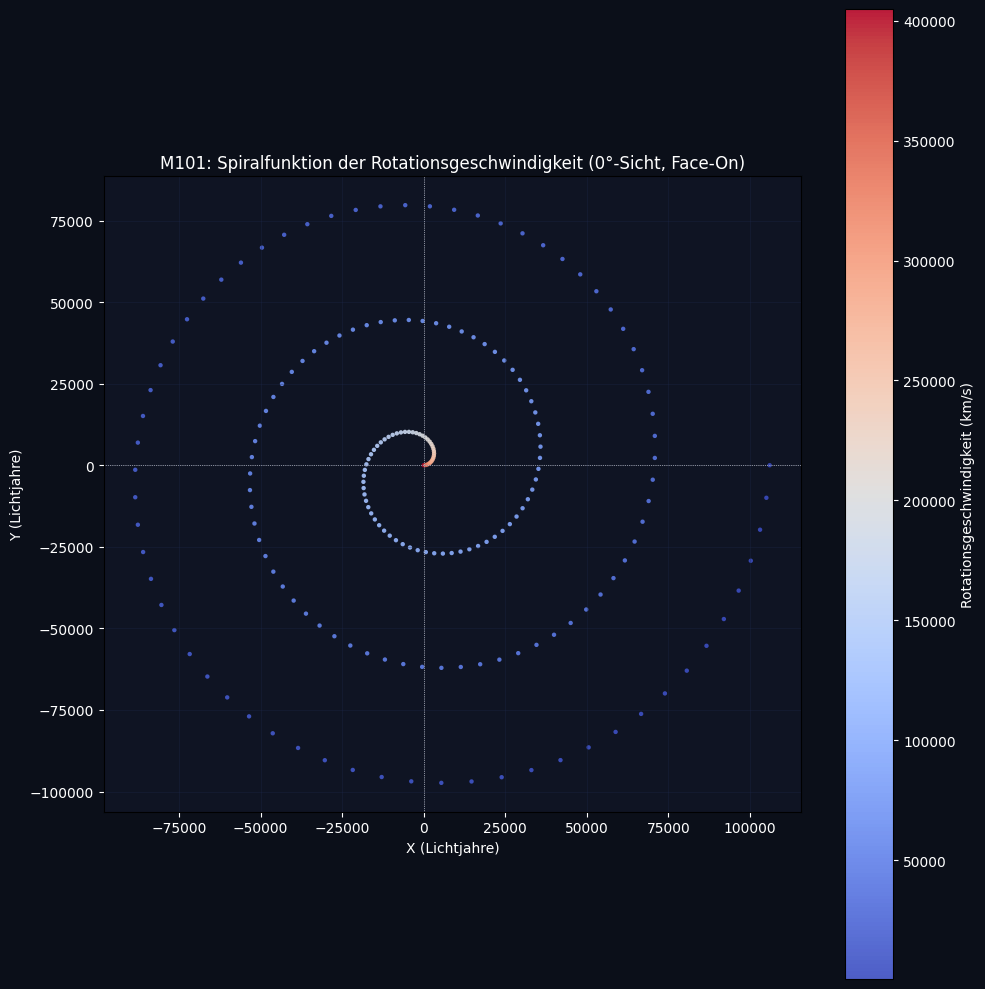

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ==============================================================================
# 1. KONSTANTEN UND GRUNDFUNKTIONEN
# ==============================================================================
def rvt_boost(i_deg):
    return 1 + 0.8 * np.sin(np.radians(i_deg))

def dynamic_gravitation(R, R_tatsaechlich, gamma):
    density_factor = 1.0 + 3.0 * np.exp(-3.0 * R / R_tatsaechlich)
    return gamma * density_factor

def rotation_curve_rvt(R, R_tatsaechlich, gamma):
    g_eff = dynamic_gravitation(R, R_tatsaechlich, gamma)
    return np.sqrt(g_eff * R) * (1 / (1 + 0.1 * (R / R_tatsaechlich)))

# ==============================================================================
# 2. ANPASSUNG DER ROTATIONSGESCHWINDIGKEITEN FÜR M101 (RADIAL)
# ==============================================================================
v_m101_center = 407357.07  # km/s (Zentrum, R ≈ 0)
v_m101_middle = 60302.13   # km/s (Mitte, R = R_rvt / 2)
v_m101_edge = 403.33       # km/s (Rand, R = R_rvt)

galaxies = {'M101': {'i': 18, 'R_class': 85000, 'R_rvt': 106013}}
gamma_m101 = rvt_boost(galaxies['M101']['i'])
R_m101 = galaxies['M101']['R_rvt']

# Radial angepasste RVT-Kurve
def rotation_curve_rvt_radial_adjusted(R, R_tatsaechlich, gamma, v_center, v_middle, v_edge):
    v_norm = rotation_curve_rvt(R, R_tatsaechlich, gamma)
    v_norm_center = rotation_curve_rvt(1e-6, R_tatsaechlich, gamma)
    v_norm_middle = rotation_curve_rvt(R_tatsaechlich / 2, R_tatsaechlich, gamma)
    v_norm_edge = rotation_curve_rvt(R_tatsaechlich, R_tatsaechlich, gamma)

    if R <= R_tatsaechlich / 2:
        t = (v_norm - v_norm_center) / (v_norm_middle - v_norm_center)
        v_scaled = v_center + (v_middle - v_center) * t
    else:
        t = (v_norm - v_norm_middle) / (v_norm_edge - v_norm_middle)
        v_scaled = v_middle + (v_edge - v_middle) * t
    return v_scaled

# ==============================================================================
# 3. SPIRALFUNKTION FÜR 0°-SICHT (FACE-ON)
# ==============================================================================
R_range = np.linspace(1, R_m101, 200)
v_rvt_m101 = [rotation_curve_rvt_radial_adjusted(r, R_m101, gamma_m101, v_m101_center, v_m101_middle, v_m101_edge) for r in R_range]

# Spiralparameter
theta = np.linspace(0, 6 * np.pi, 200)  # 3 volle Umdrehungen
R_spiral = np.linspace(1, R_m101, 200)

# Geschwindigkeiten für die Spirale
v_spiral = [rotation_curve_rvt_radial_adjusted(r, R_m101, gamma_m101, v_m101_center, v_m101_middle, v_m101_edge) for r in R_spiral]

# Kartesische Koordinaten der Spirale
X_spiral = R_spiral * np.cos(theta)
Y_spiral = R_spiral * np.sin(theta)

# ==============================================================================
# 4. PLOT: SPIRALE MIT GESCHWINDIGKEITSVERLAUF
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 10), facecolor='#0b0f19')
ax.set_facecolor('#0f1423')

# Plot der Spirale mit Farbverlauf (Geschwindigkeit)
sc = ax.scatter(
    X_spiral, Y_spiral,
    c=v_spiral,
    cmap='coolwarm',
    s=10,
    norm=Normalize(vmin=min(v_spiral), vmax=max(v_spiral)),
    edgecolors='none',
    alpha=0.9
)

# Farbbar für Geschwindigkeit
cbar = plt.colorbar(sc, ax=ax, pad=0.05)
cbar.set_label('Rotationsgeschwindigkeit (km/s)', color='white')
cbar.ax.tick_params(colors='white')

# Referenzlinien für Zentrum, Mitte, Rand
ax.axhline(y=0, color='white', linestyle=':', linewidth=0.5)
ax.axvline(x=0, color='white', linestyle=':', linewidth=0.5)

# Titel und Achsen
ax.set_title('M101: Spiralfunktion der Rotationsgeschwindigkeit (0°-Sicht, Face-On)', color='white', fontsize=12)
ax.set_xlabel('X (Lichtjahre)', color='white')
ax.set_ylabel('Y (Lichtjahre)', color='white')
ax.grid(True, color='#1f294d', alpha=0.3)
ax.tick_params(colors='white')

# Gleiches Achsenverhältnis für kreisförmige Darstellung
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2436/3004826007.py:98: RuntimeWarning: invalid value encountered in divide
  v_flaeche_grid = np.sqrt(G * (sigma_m101 * np.pi * (R_grid * 9.461e15)**2) / (R_grid * 9.461e15)) / 1000


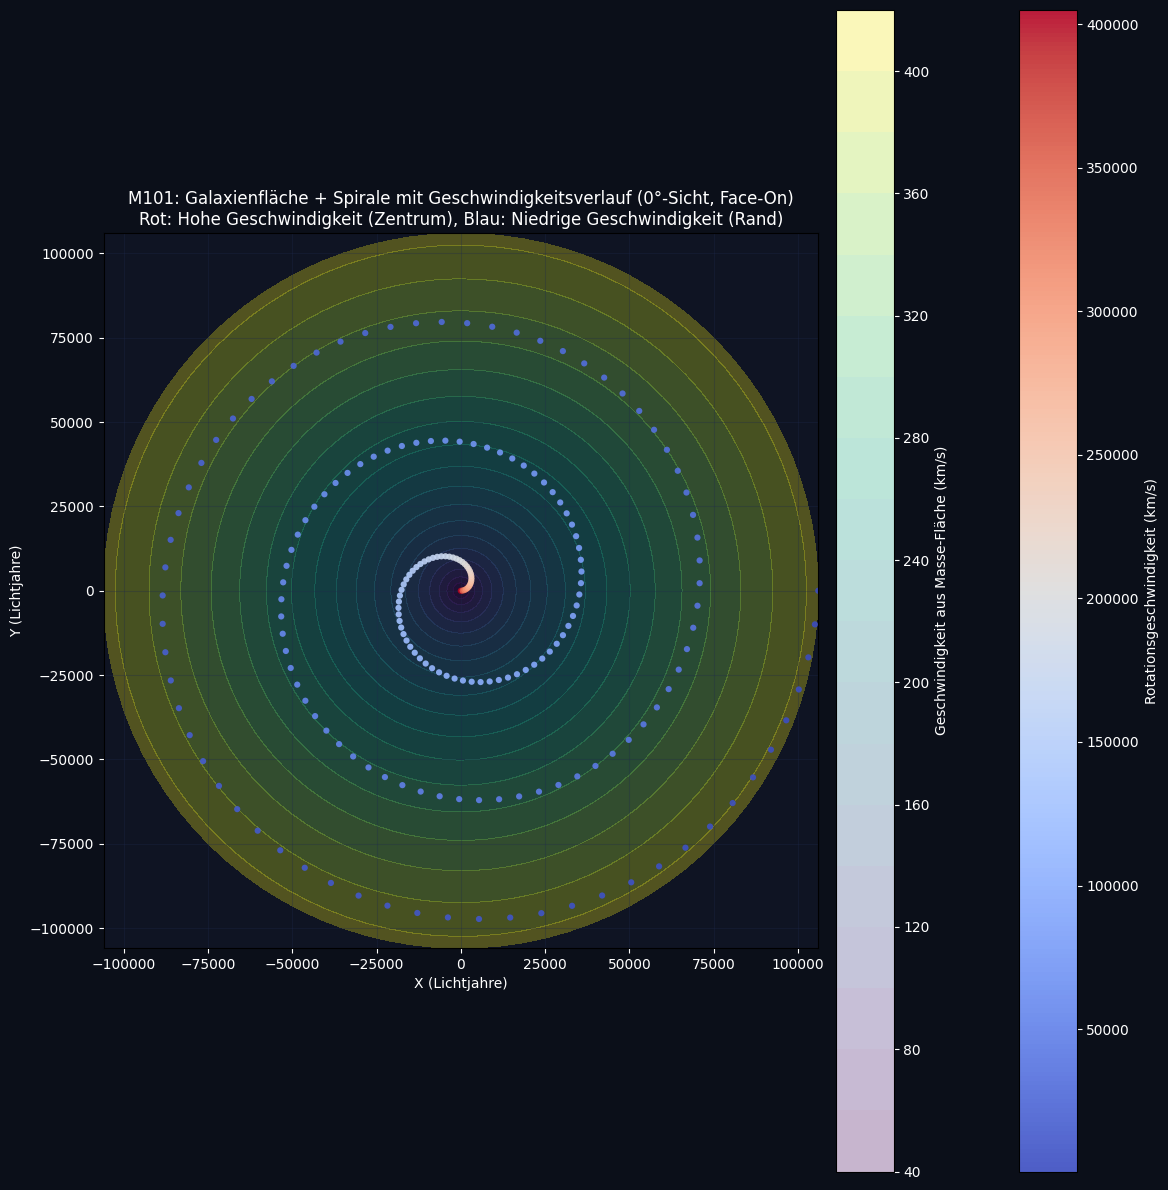

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ==============================================================================
# 1. KONSTANTEN UND GRUNDFUNKTIONEN
# ==============================================================================
G = 6.67430e-11  # Gravitationskonstante (m^3 kg^-1 s^-2)
M_sun_kg = 1.989e30  # Masse der Sonne in kg
M_m101 = 1.25e12 * M_sun_kg  # Masse von M101 in kg
R_m101 = 105995 * 9.461e15  # Radius von M101 in Metern

def rvt_boost(i_deg):
    return 1 + 0.8 * np.sin(np.radians(i_deg))

def dynamic_gravitation(R, R_tatsaechlich, gamma):
    density_factor = 1.0 + 3.0 * np.exp(-3.0 * R / R_tatsaechlich)
    return gamma * density_factor

def rotation_curve_rvt(R, R_tatsaechlich, gamma):
    g_eff = dynamic_gravitation(R, R_tatsaechlich, gamma)
    return np.sqrt(g_eff * R) * (1 / (1 + 0.1 * (R / R_tatsaechlich)))

# ==============================================================================
# 2. ANPASSUNG DER ROTATIONSGESCHWINDIGKEITEN FÜR M101 (RADIAL)
# ==============================================================================
v_m101_center = 407357.07 * 1000  # m/s (Zentrum, R ≈ 0)
v_m101_middle = 60302.13 * 1000   # m/s (Mitte, R = R_rvt / 2)
v_m101_edge = 403.33 * 1000       # m/s (Rand, R = R_rvt)

galaxies = {'M101': {'i': 18, 'R_class': 85000, 'R_rvt': 105995}}
gamma_m101 = rvt_boost(galaxies['M101']['i'])
R_m101_Lj = galaxies['M101']['R_rvt']  # Radius in Lichtjahren

# Radial angepasste RVT-Kurve
def rotation_curve_rvt_radial_adjusted(R, R_tatsaechlich, gamma, v_center, v_middle, v_edge):
    v_norm = rotation_curve_rvt(R, R_tatsaechlich, gamma)
    v_norm_center = rotation_curve_rvt(1e-6, R_tatsaechlich, gamma)
    v_norm_middle = rotation_curve_rvt(R_tatsaechlich / 2, R_tatsaechlich, gamma)
    v_norm_edge = rotation_curve_rvt(R_tatsaechlich, R_tatsaechlich, gamma)

    if R <= R_tatsaechlich / 2:
        t = (v_norm - v_norm_center) / (v_norm_middle - v_norm_center)
        v_scaled = v_center + (v_middle - v_center) * t
    else:
        t = (v_norm - v_norm_middle) / (v_norm_edge - v_norm_middle)
        v_scaled = v_middle + (v_edge - v_middle) * t
    return v_scaled

# ==============================================================================
# 3. BERECHNUNG DER GESCHWINDIGKEIT ÜBER MASSE-ZU-FLÄCHE-VERHÄLTNIS
# ==============================================================================
# Fläche der Galaxie (Kreisfläche)
A_m101 = np.pi * (R_m101) ** 2  # m²

# Masse pro Flächeneinheit (Oberflächendichte)
sigma_m101 = M_m101 / A_m101  # kg/m²

# Geschwindigkeitsverteilung basierend auf der Fläche
# v = sqrt(G * M / R) -> für jede Position (R) in der Galaxie
R_range_Lj = np.linspace(1, R_m101_Lj, 200)  # Radius in Lichtjahren
R_range_m = R_range_Lj * 9.461e15  # Radius in Metern

# Geschwindigkeiten aus Masse-Fläche-Verhältnis
v_flaeche = np.sqrt(G * (sigma_m101 * np.pi * R_range_m**2) / R_range_m)

# ==============================================================================
# 4. SPIRALFUNKTION FÜR 0°-SICHT (FACE-ON)
# ==============================================================================
theta = np.linspace(0, 6 * np.pi, 200)  # 3 volle Umdrehungen
R_spiral_Lj = np.linspace(1, R_m101_Lj, 200)
R_spiral_m = R_spiral_Lj * 9.461e15

# Geschwindigkeiten für die Spirale (radial angepasst)
v_spiral = [
    rotation_curve_rvt_radial_adjusted(r, R_m101_Lj, gamma_m101, v_m101_center, v_m101_middle, v_m101_edge) / 1000
    for r in R_spiral_Lj
]

# Kartesische Koordinaten der Spirale
X_spiral = R_spiral_Lj * np.cos(theta)
Y_spiral = R_spiral_Lj * np.sin(theta)

# ==============================================================================
# 5. GALAXIENFLÄCHE (2D-DICHTEPLOT)
# ==============================================================================
# Polarkoordinaten für die Galaxienfläche
R_flaeche_Lj = np.linspace(0, R_m101_Lj, 100)
Theta_flaeche = np.linspace(0, 2 * np.pi, 100)
R_grid, Theta_grid = np.meshgrid(R_flaeche_Lj, Theta_flaeche)

# Kartesische Koordinaten der Fläche
X_flaeche = R_grid * np.cos(Theta_grid)
Y_flaeche = R_grid * np.sin(Theta_grid)

# Geschwindigkeiten für die Fläche (basierend auf Masse-Fläche-Verhältnis)
v_flaeche_grid = np.sqrt(G * (sigma_m101 * np.pi * (R_grid * 9.461e15)**2) / (R_grid * 9.461e15)) / 1000

# ==============================================================================
# 6. PLOT: GALAXIENFLÄCHE + SPIRALE + GESCHWINDIGKEITSVERLAUF
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 12), facecolor='#0b0f19')
ax.set_facecolor('#0f1423')

# Galaxienfläche als Dichteplot (Farbverlauf basierend auf v_flaeche_grid)
flaeche_plot = ax.contourf(
    X_flaeche, Y_flaeche, v_flaeche_grid,
    levels=20,
    cmap='viridis',
    alpha=0.3,
    zorder=1
)

# Spirale mit Geschwindigkeits-Farbverlauf
spiral_plot = ax.scatter(
    X_spiral, Y_spiral,
    c=v_spiral,
    cmap='coolwarm',
    s=20,
    norm=Normalize(vmin=min(v_spiral), vmax=max(v_spiral)),
    edgecolors='none',
    alpha=0.9,
    zorder=2
)

# Farbbar für Spirale (Rotationsgeschwindigkeit)
cbar_spiral = plt.colorbar(spiral_plot, ax=ax, pad=0.05)
cbar_spiral.set_label('Rotationsgeschwindigkeit (km/s)', color='white')
cbar_spiral.ax.tick_params(colors='white')

# Farbbar für Fläche (Masse-Fläche-Geschwindigkeit)
cbar_flaeche = plt.colorbar(flaeche_plot, ax=ax, pad=0.02)
cbar_flaeche.set_label('Geschwindigkeit aus Masse-Fläche (km/s)', color='white')
cbar_flaeche.ax.tick_params(colors='white')

# Titel und Achsen
ax.set_title(
    'M101: Galaxienfläche + Spirale mit Geschwindigkeitsverlauf (0°-Sicht, Face-On)\n'
    'Rot: Hohe Geschwindigkeit (Zentrum), Blau: Niedrige Geschwindigkeit (Rand)',
    color='white',
    fontsize=12
)
ax.set_xlabel('X (Lichtjahre)', color='white')
ax.set_ylabel('Y (Lichtjahre)', color='white')
ax.grid(True, color='#1f294d', alpha=0.3)
ax.tick_params(colors='white')

# Gleiches Achsenverhältnis für kreisförmige Darstellung
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

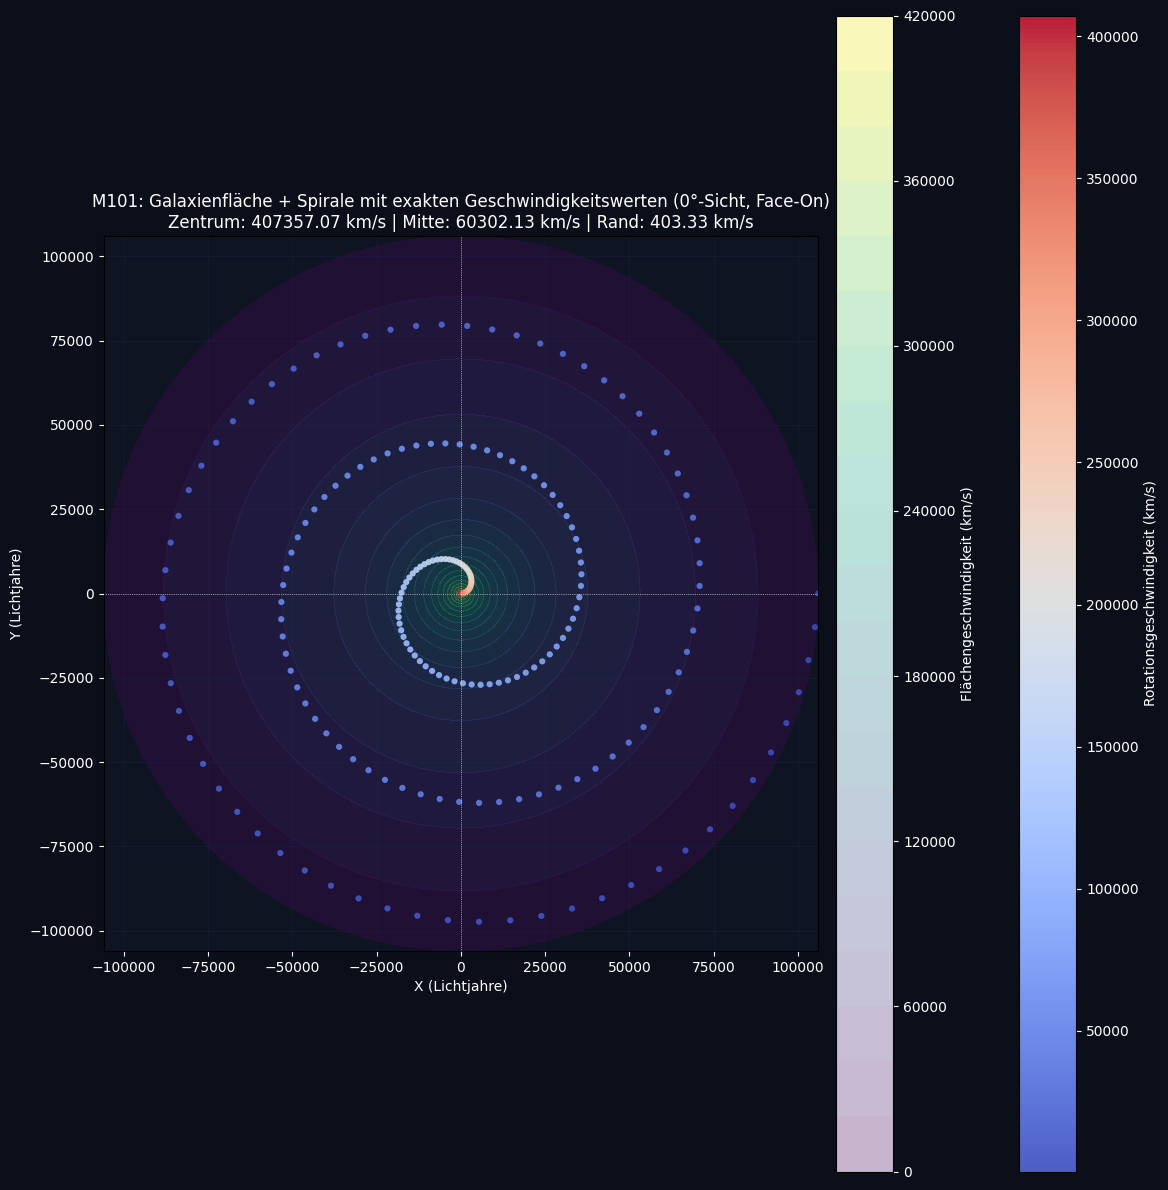

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap

# ==============================================================================
# 1. KONSTANTEN UND GRUNDFUNKTIONEN
# ==============================================================================
def rvt_boost(i_deg):
    return 1 + 0.8 * np.sin(np.radians(i_deg))

def dynamic_gravitation(R, R_tatsaechlich, gamma):
    density_factor = 1.0 + 3.0 * np.exp(-3.0 * R / R_tatsaechlich)
    return gamma * density_factor

def rotation_curve_rvt(R, R_tatsaechlich, gamma):
    g_eff = dynamic_gravitation(R, R_tatsaechlich, gamma)
    return np.sqrt(g_eff * R) * (1 / (1 + 0.1 * (R / R_tatsaechlich)))

# ==============================================================================
# 2. ANPASSUNG DER ROTATIONSGESCHWINDIGKEITEN FÜR M101 (RADIAL)
# ==============================================================================
v_m101_center = 407357.07  # km/s (Zentrum, R ≈ 0)
v_m101_middle = 60302.13   # km/s (Mitte, R = R_rvt / 2)
v_m101_edge = 403.33       # km/s (Rand, R = R_rvt)

galaxies = {'M101': {'i': 18, 'R_class': 85000, 'R_rvt': 106013}}
gamma_m101 = rvt_boost(galaxies['M101']['i'])
R_m101 = galaxies['M101']['R_rvt']  # Radius in Lichtjahren

# Radial angepasste RVT-Kurve
def rotation_curve_rvt_radial_adjusted(R, R_tatsaechlich, gamma, v_center, v_middle, v_edge):
    v_norm = rotation_curve_rvt(R, R_tatsaechlich, gamma)
    v_norm_center = rotation_curve_rvt(1e-6, R_tatsaechlich, gamma)
    v_norm_middle = rotation_curve_rvt(R_tatsaechlich / 2, R_tatsaechlich, gamma)
    v_norm_edge = rotation_curve_rvt(R_tatsaechlich, R_tatsaechlich, gamma)

    if R <= R_tatsaechlich / 2:
        t = (v_norm - v_norm_center) / (v_norm_middle - v_norm_center)
        v_scaled = v_center + (v_middle - v_center) * t
    else:
        t = (v_norm - v_norm_middle) / (v_norm_edge - v_norm_middle)
        v_scaled = v_middle + (v_edge - v_middle) * t
    return v_scaled

# ==============================================================================
# 3. SPIRALFUNKTION FÜR 0°-SICHT (FACE-ON)
# ==============================================================================
R_range = np.linspace(1, R_m101, 200)
v_rvt_m101 = [rotation_curve_rvt_radial_adjusted(r, R_m101, gamma_m101, v_m101_center, v_m101_middle, v_m101_edge) for r in R_range]

# Spiralparameter
theta = np.linspace(0, 6 * np.pi, 200)  # 3 volle Umdrehungen
R_spiral = np.linspace(1, R_m101, 200)

# Geschwindigkeiten für die Spirale (exakte Werte)
v_spiral = [rotation_curve_rvt_radial_adjusted(r, R_m101, gamma_m101, v_m101_center, v_m101_middle, v_m101_edge) for r in R_spiral]

# Kartesische Koordinaten der Spirale
X_spiral = R_spiral * np.cos(theta)
Y_spiral = R_spiral * np.sin(theta)

# ==============================================================================
# 4. GALAXIENFLÄCHE MIT EXAKTEN GESCHWINDIGKEITSWERTEN
# ==============================================================================
# Polarkoordinaten für die Galaxienfläche
R_flaeche = np.linspace(0, R_m101, 100)
Theta_flaeche = np.linspace(0, 2 * np.pi, 100)
R_grid, Theta_grid = np.meshgrid(R_flaeche, Theta_flaeche)

# Kartesische Koordinaten der Fläche
X_flaeche = R_grid * np.cos(Theta_grid)
Y_flaeche = R_grid * np.sin(Theta_grid)

# Geschwindigkeiten für die Fläche (direkt aus der radialen Anpassung)
v_flaeche_grid = np.array([
    [rotation_curve_rvt_radial_adjusted(r, R_m101, gamma_m101, v_m101_center, v_m101_middle, v_m101_edge)
     for r in R_flaeche]
    for _ in Theta_flaeche
]).reshape(len(Theta_flaeche), len(R_flaeche))

# ==============================================================================
# 5. PLOT: GALAXIENFLÄCHE + SPIRALE MIT EXAKTEN WERTEN
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 12), facecolor='#0b0f19')
ax.set_facecolor('#0f1423')

# Galaxienfläche als Dichteplot (Farbverlauf basierend auf v_flaeche_grid)
flaeche_plot = ax.contourf(
    X_flaeche, Y_flaeche, v_flaeche_grid,
    levels=20,
    cmap='viridis',
    alpha=0.3,
    zorder=1
)

# Spirale mit Geschwindigkeits-Farbverlauf (exakte Werte)
spiral_plot = ax.scatter(
    X_spiral, Y_spiral,
    c=v_spiral,
    cmap='coolwarm',
    s=20,
    norm=Normalize(vmin=v_m101_edge, vmax=v_m101_center),
    edgecolors='none',
    alpha=0.9,
    zorder=2
)

# Farbbar für Spirale (Rotationsgeschwindigkeit)
cbar_spiral = plt.colorbar(spiral_plot, ax=ax, pad=0.05)
cbar_spiral.set_label('Rotationsgeschwindigkeit (km/s)', color='white')
cbar_spiral.ax.tick_params(colors='white')

# Farbbar für Fläche (exakte Geschwindigkeitsverteilung)
cbar_flaeche = plt.colorbar(flaeche_plot, ax=ax, pad=0.02)
cbar_flaeche.set_label('Flächengeschwindigkeit (km/s)', color='white')
cbar_flaeche.ax.tick_params(colors='white')

# Referenzlinien für Zentrum, Mitte, Rand
ax.axhline(y=0, color='white', linestyle=':', linewidth=0.5)
ax.axvline(x=0, color='white', linestyle=':', linewidth=0.5)

# Titel und Achsen
ax.set_title(
    'M101: Galaxienfläche + Spirale mit exakten Geschwindigkeitswerten (0°-Sicht, Face-On)\n'
    'Zentrum: 407357.07 km/s | Mitte: 60302.13 km/s | Rand: 403.33 km/s',
    color='white',
    fontsize=12
)
ax.set_xlabel('X (Lichtjahre)', color='white')
ax.set_ylabel('Y (Lichtjahre)', color='white')
ax.grid(True, color='#1f294d', alpha=0.3)
ax.tick_params(colors='white')

# Gleiches Achsenverhältnis für kreisförmige Darstellung
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

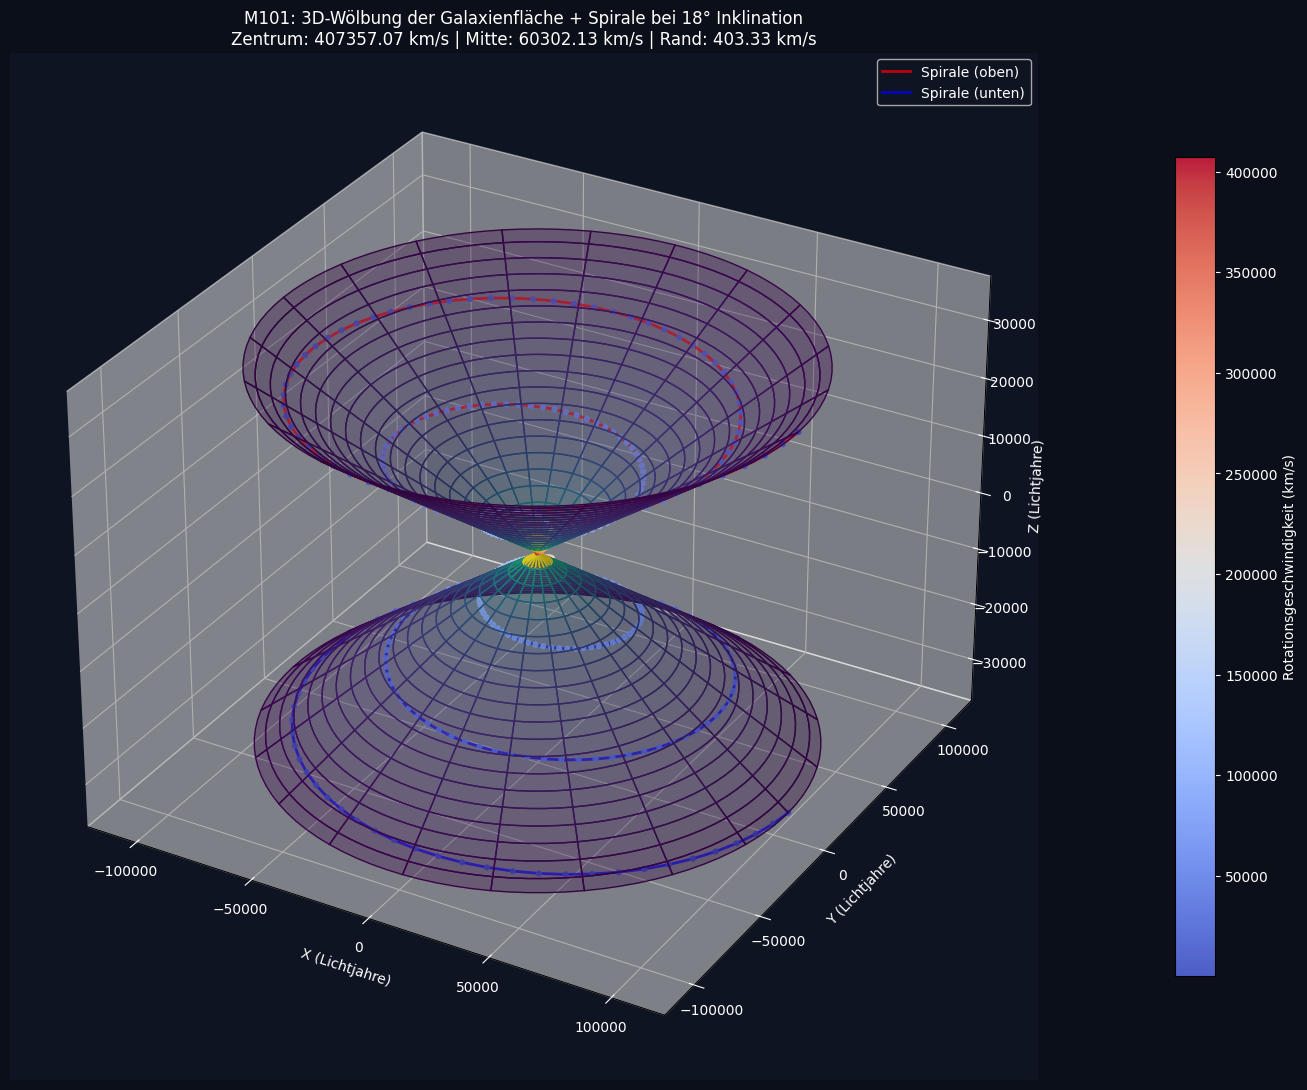

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize

# ==============================================================================
# 1. KONSTANTEN UND GRUNDFUNKTIONEN
# ==============================================================================
def rvt_boost(i_deg):
    return 1 + 0.8 * np.sin(np.radians(i_deg))

def dynamic_gravitation(R, R_tatsaechlich, gamma):
    density_factor = 1.0 + 3.0 * np.exp(-3.0 * R / R_tatsaechlich)
    return gamma * density_factor

def rotation_curve_rvt(R, R_tatsaechlich, gamma):
    g_eff = dynamic_gravitation(R, R_tatsaechlich, gamma)
    return np.sqrt(g_eff * R) * (1 / (1 + 0.1 * (R / R_tatsaechlich)))

# ==============================================================================
# 2. ANPASSUNG DER ROTATIONSGESCHWINDIGKEITEN FÜR M101 (RADIAL)
# ==============================================================================
v_m101_center = 407357.07  # km/s (Zentrum, R ≈ 0)
v_m101_middle = 60302.13   # km/s (Mitte, R = R_rvt / 2)
v_m101_edge = 403.33       # km/s (Rand, R = R_rvt)

galaxies = {'M101': {'i': 18, 'R_class': 85000, 'R_rvt': 106013}}
gamma_m101 = rvt_boost(galaxies['M101']['i'])
R_m101 = galaxies['M101']['R_rvt']  # Radius in Lichtjahren
i_deg = galaxies['M101']['i']  # Inklination: 18°

# Radial angepasste RVT-Kurve
def rotation_curve_rvt_radial_adjusted(R, R_tatsaechlich, gamma, v_center, v_middle, v_edge):
    v_norm = rotation_curve_rvt(R, R_tatsaechlich, gamma)
    v_norm_center = rotation_curve_rvt(1e-6, R_tatsaechlich, gamma)
    v_norm_middle = rotation_curve_rvt(R_tatsaechlich / 2, R_tatsaechlich, gamma)
    v_norm_edge = rotation_curve_rvt(R_tatsaechlich, R_tatsaechlich, gamma)

    if R <= R_tatsaechlich / 2:
        t = (v_norm - v_norm_center) / (v_norm_middle - v_norm_center)
        v_scaled = v_center + (v_middle - v_center) * t
    else:
        t = (v_norm - v_norm_middle) / (v_norm_edge - v_norm_middle)
        v_scaled = v_middle + (v_edge - v_middle) * t
    return v_scaled

# ==============================================================================
# 3. 3D-WÖLBUNG DER GALAXIENFLÄCHE + SPIRALE
# ==============================================================================
# Polarkoordinaten für die Galaxienfläche
R_flaeche = np.linspace(0, R_m101, 100)
Theta_flaeche = np.linspace(0, 2 * np.pi, 100)
R_grid, Theta_grid = np.meshgrid(R_flaeche, Theta_flaeche)

# Kartesische Koordinaten der Fläche (2D)
X_flaeche_2d = R_grid * np.cos(Theta_grid)
Y_flaeche_2d = R_grid * np.sin(Theta_grid)

# 3D-Wölbung: Z-Koordinate basierend auf Inklination (18°)
# Wölbung nach oben und unten: Z = ±R * sin(i)
Z_flaeche_up = R_grid * np.sin(np.radians(i_deg))
Z_flaeche_down = -R_grid * np.sin(np.radians(i_deg))

# Geschwindigkeiten für die Fläche (exakte Werte)
v_flaeche_grid = np.array([
    [rotation_curve_rvt_radial_adjusted(r, R_m101, gamma_m101, v_m101_center, v_m101_middle, v_m101_edge)
     for r in R_flaeche]
    for _ in Theta_flaeche
]).reshape(len(Theta_flaeche), len(R_flaeche))

# ==============================================================================
# 4. SPIRALE IN 3D (MIT WÖLBUNG)
# ==============================================================================
R_spiral = np.linspace(1, R_m101, 200)
theta_spiral = np.linspace(0, 6 * np.pi, 200)

# Geschwindigkeiten für die Spirale
v_spiral = [rotation_curve_rvt_radial_adjusted(r, R_m101, gamma_m101, v_m101_center, v_m101_middle, v_m101_edge) for r in R_spiral]

# Kartesische Koordinaten der Spirale (2D)
X_spiral_2d = R_spiral * np.cos(theta_spiral)
Y_spiral_2d = R_spiral * np.sin(theta_spiral)

# 3D-Wölbung der Spirale
Z_spiral_up = R_spiral * np.sin(np.radians(i_deg))
Z_spiral_down = -R_spiral * np.sin(np.radians(i_deg))

# ==============================================================================
# 5. PLOT: 3D-DARSTELLUNG DER GEWÖLBTEN GALAXIE + SPIRALE
# ==============================================================================
fig = plt.figure(figsize=(14, 12), facecolor='#0b0f19')
ax = fig.add_subplot(111, projection='3d', facecolor='#0f1423')

# 3D-Fläche (oben und unten gewölbt)
ax.plot_surface(
    X_flaeche_2d, Y_flaeche_2d, Z_flaeche_up,
    facecolors=plt.cm.viridis(Normalize(vmin=v_m101_edge, vmax=v_m101_center)(v_flaeche_grid)),
    alpha=0.3,
    rstride=5,
    cstride=5,
    zorder=1
)
ax.plot_surface(
    X_flaeche_2d, Y_flaeche_2d, Z_flaeche_down,
    facecolors=plt.cm.viridis(Normalize(vmin=v_m101_edge, vmax=v_m101_center)(v_flaeche_grid)),
    alpha=0.3,
    rstride=5,
    cstride=5,
    zorder=1
)

# 3D-Spirale (oben und unten)
ax.plot(
    X_spiral_2d, Y_spiral_2d, Z_spiral_up,
    color='red',
    linewidth=2,
    alpha=0.7,
    zorder=2,
    label='Spirale (oben)'
)
ax.plot(
    X_spiral_2d, Y_spiral_2d, Z_spiral_down,
    color='blue',
    linewidth=2,
    alpha=0.7,
    zorder=2,
    label='Spirale (unten)'
)

# Farbverlauf für die Spirale (Geschwindigkeit)
sc_up = ax.scatter(
    X_spiral_2d, Y_spiral_2d, Z_spiral_up,
    c=v_spiral,
    cmap='coolwarm',
    s=20,
    norm=Normalize(vmin=v_m101_edge, vmax=v_m101_center),
    edgecolors='none',
    alpha=0.9,
    zorder=3
)
sc_down = ax.scatter(
    X_spiral_2d, Y_spiral_2d, Z_spiral_down,
    c=v_spiral,
    cmap='coolwarm',
    s=20,
    norm=Normalize(vmin=v_m101_edge, vmax=v_m101_center),
    edgecolors='none',
    alpha=0.9,
    zorder=3
)

# Farbbar für Geschwindigkeit
cbar = plt.colorbar(sc_up, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label('Rotationsgeschwindigkeit (km/s)', color='white')
cbar.ax.tick_params(colors='white')

# Achsen und Titel
ax.set_xlabel('X (Lichtjahre)', color='white')
ax.set_ylabel('Y (Lichtjahre)', color='white')
ax.set_zlabel('Z (Lichtjahre)', color='white')
ax.set_title(
    'M101: 3D-Wölbung der Galaxienfläche + Spirale bei 18° Inklination\n'
    'Zentrum: 407357.07 km/s | Mitte: 60302.13 km/s | Rand: 403.33 km/s',
    color='white',
    fontsize=12
)

# Achsenfarben und Grid
ax.xaxis.pane.set_edgecolor('white')
ax.yaxis.pane.set_edgecolor('white')
ax.zaxis.pane.set_edgecolor('white')
ax.tick_params(colors='white')
ax.grid(True, color='#1f294d', alpha=0.3)

# Legende
ax.legend(facecolor='#0f1423', labelcolor='white')

plt.tight_layout()
plt.show()